In [1]:
import numpy as np
import pandas as pd


In [3]:
data = pd.read_csv('powerplant_data.csv')

In [4]:
data.head()

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43


In [5]:
# AT => Temperature
# V => vaccum
# AP => presure
# RH => humiditty
# y => PE => Produced Energy
data.isnull().sum()


AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

In [6]:
X = data.drop("PE",axis = 1)
X
y = data['PE']
y

0       480.48
1       445.75
2       438.76
3       453.09
4       464.43
         ...  
9563    462.59
9564    432.90
9565    465.96
9566    450.93
9567    451.67
Name: PE, Length: 9568, dtype: float64

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [8]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state = 42)
X_train
X_test
y_train
y_test
data.shape

(9568, 5)

In [9]:
standard_scaler = StandardScaler()
X_train_scaled = standard_scaler.fit_transform(X_train)
X_train_scaled
X_test_scaled = standard_scaler.fit_transform(X_test)
X_test_scaled

array([[ 1.36255441,  0.24305848, -1.27798491, -1.04586379],
       [ 0.82147733,  1.36986442, -0.74695303,  0.31071896],
       [-0.247116  , -0.73708132,  1.92304887, -0.14668594],
       ...,
       [-0.67970645, -1.15815506, -0.31652036, -0.05697206],
       [ 1.33136451,  1.34463153, -0.87558808, -0.39000089],
       [-0.26474508, -0.26711887,  0.33984824,  1.14397069]])

In [10]:
import torch
import torch.nn as nn

In [11]:
X_train_tensor = torch.tensor(X_train_scaled , dtype = torch.float32)
y_train_tensor = torch.tensor(y_train.values , dtype = torch.float32).view(-1,1)
X_test_tensor = torch.tensor(X_test_scaled , dtype = torch.float32)
y_test_tensor = torch.tensor(y_test.values , dtype = torch.float32).view(-1,1)

X_train_tensor
y_train_tensor
X_test_tensor
y_test

2513    433.27
9411    438.16
8745    458.42
9085    480.82
4950    441.41
         ...  
7204    456.70
1599    438.04
5697    467.80
350     437.14
6210    456.78
Name: PE, Length: 1914, dtype: float64

In [12]:
type(X_train_scaled)
type(X_train_tensor)
type(y_train)
y_train.values
type(y_train.values)
type(y_train_tensor)


torch.Tensor

In [23]:
from torch.utils.data import TensorDataset , DataLoader

In [24]:
train_dataset = TensorDataset(X_train_tensor,y_train_tensor)
test_dataset = TensorDataset(X_test_tensor,y_test_tensor)

In [25]:
train_loader = DataLoader(train_dataset,batch_size = 32 ,shuffle = True)
test_loader = DataLoader(test_dataset,batch_size = 32)

In [26]:
class ANN (nn.Module):
    def __init__(self):
        super().__init__()
        self.model=nn.Sequential(
            # 1st hidden layer
            nn.Linear(X_train.shape[1],6),
            nn.ReLU(),

            # 2nd hidden layer
            nn.Linear(6,6),
            nn.ReLU(),

            # output layer
            nn.Linear(6,1)
        )
    def forward(self,x):
        return self.model(x)
        
        
        

In [27]:
import torch
import torch.nn as nn
import torch.optim as optim

model = ANN()

criteria = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [28]:
epochs = 100

train_loss = []
validation_loss = []
best_value_loss = float("inf")
for epoch in range(epochs):

    # =========================
    # Training
    # =========================
    model.train()
    running_loss = 0.0

    for xb, yb in train_loader:

        optimizer.zero_grad()

        # Forward propagation
        outputs = model(xb)

        # Calculate loss
        loss = criteria(outputs, yb)

        # Backpropagation
        loss.backward()

        # Update parameters
        optimizer.step()

        # Accumulate loss
        running_loss += loss.item()

    epoch_train_loss = running_loss / len(train_loader)
    train_loss.append(epoch_train_loss)


    # =========================
    # Validation
    # =========================
    model.eval()
    running_val_loss = 0.0

    with torch.no_grad():

        for xb, yb in test_loader:

            # Forward propagation
            outputs = model(xb)

            # Calculate validation loss
            loss = criteria(outputs, yb)

            # Accumulate validation loss
            running_val_loss += loss.item()

    epoch_val_loss = running_val_loss / len(test_loader)
    validation_loss.append(epoch_val_loss)

    if epoch_val_loss<best_value_loss:
        best_value_loss = epoch_val_loss
        torch.save(model.state_dict() , "best_model.pt")
        


    # Print results for this epoch
    print(
        f"Epoch {epoch + 1}/{epochs} "
        f"==> Training Loss: {epoch_train_loss:.4f} "
        f"Validation Loss: {epoch_val_loss:.4f}"
    )

Epoch 1/100 ==> Training Loss: 206101.2362 Validation Loss: 203225.4591
Epoch 2/100 ==> Training Loss: 193167.3695 Validation Loss: 177756.5255
Epoch 3/100 ==> Training Loss: 154459.7871 Validation Loss: 129461.1438
Epoch 4/100 ==> Training Loss: 107059.8036 Validation Loss: 87758.5553
Epoch 5/100 ==> Training Loss: 74944.1047 Validation Loss: 62314.1000
Epoch 6/100 ==> Training Loss: 52362.8163 Validation Loss: 40998.0949
Epoch 7/100 ==> Training Loss: 32348.2254 Validation Loss: 22678.0061
Epoch 8/100 ==> Training Loss: 16451.6516 Validation Loss: 10125.6280
Epoch 9/100 ==> Training Loss: 7499.3068 Validation Loss: 5225.5687
Epoch 10/100 ==> Training Loss: 4762.1022 Validation Loss: 3963.9383
Epoch 11/100 ==> Training Loss: 3805.9009 Validation Loss: 3257.1679
Epoch 12/100 ==> Training Loss: 3153.5213 Validation Loss: 2714.1297
Epoch 13/100 ==> Training Loss: 2647.3528 Validation Loss: 2288.0064
Epoch 14/100 ==> Training Loss: 2239.6264 Validation Loss: 1947.2891
Epoch 15/100 ==> Tra

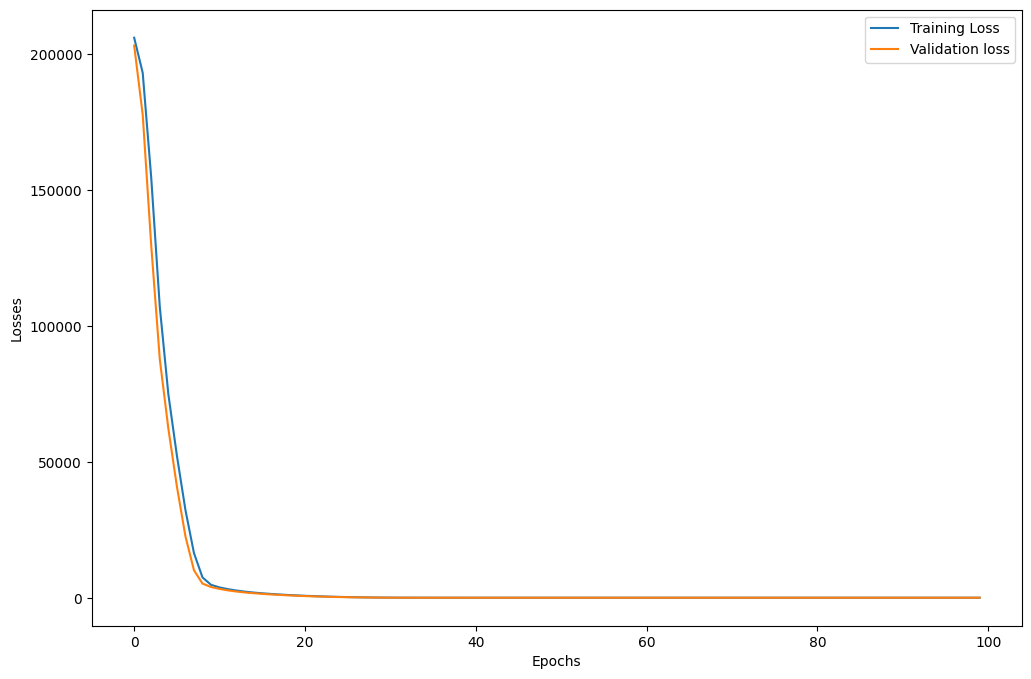

In [29]:
import matplotlib.pyplot as plt
loss_df = pd.DataFrame({
    "Training" : train_loss,
    "Validation" : validation_loss
}
)
plt.figure(figsize = (12,8))

plt.plot(loss_df['Training'] , label = "Training Loss")
plt.plot(loss_df["Validation"] , label = "Validation loss")
plt.xlabel("Epochs")
plt.ylabel("Losses")
plt.legend()

In [30]:
model.load_state_dict(torch.load("best_model.pt"))

<All keys matched successfully>

In [31]:
# evaluation 
model.eval()
with torch.no_grad():
    train_preds = model(X_train_tensor)
    test_preds = model(X_test_tensor)
    train_mse_loss = criteria(train_preds , y_train_tensor)
    test_mse_loss = criteria(test_preds , y_test_tensor)
print(train_mse_loss)
print(test_mse_loss)


tensor(20.4621)
tensor(18.8745)


In [33]:
from sklearn.metrics import r2_score
r2_score = r2_score(y_test , test_preds)

In [36]:



predicted_df = pd.DataFrame(test_preds.numpy(), columns=["predicted values"])
actual_df = pd.DataFrame(y_test_tensor.numpy(), columns=["actual values"])

result_df = pd.concat([predicted_df, actual_df], axis=1)

result_df


,predicted values,actual values
0,435.246094,433.269989
1,436.709747,438.160004
2,461.323608,458.420013
3,476.428284,480.820007
4,435.095581,441.410004
...,...,...
1909,451.403687,456.700012
1910,431.433228,438.040009
1911,467.986938,467.799988
1912,430.821777,437.140015
